# SiT Inference + w/o CFG

In [8]:
%load_ext autoreload
%autoreload 2
import h5py
import numpy as np


import os
from PIL import Image
import numpy as np
from matplotlib import pyplot as plt

import gc
import torch
import torchvision
from torchvision.utils import make_grid
import torchvision.transforms.functional as TF

from lightning.pytorch import Trainer
from torch.utils.data import Dataset, DataLoader

from jutils import ims_to_grid
from jutils.nn import AutoencoderKL
from jutils import tensor2im, freeze

while not os.path.exists('ldm'):
    %cd ..
assert os.path.exists('ldm')


from data_processing.tools.norm import denorm_tensor
from ldm.dataloader.dataloader.hdf5_dataloader import HDF5DataModule
from ldm.frameworks.flow.fm import FlowModel
from ldm.models.transformer.dit import DiT_models


DEV = "cuda:3" if torch.cuda.is_available() else "cpu"
torch.cuda.empty_cache()
gc.collect()

print(f"Memory Allocated: {torch.cuda.memory_allocated(DEV) / 1024 ** 3:.2f} GB")
print(f"Memory Cached: {torch.cuda.memory_reserved(DEV) / 1024 ** 3:.2f} GB")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Memory Allocated: 2.85 GB
Memory Cached: 5.18 GB


In [9]:
##############################
# Data parameters
##############################
source_timestep = 0.00
target_timestep = 1.00

class_labels    = [250, 236, 291, 292, 294, 296, 339, 340]
data_dir        = 'dataset/processed/testset-256/imagenet256-test-dataset-T110525.hdf5'

-----
## Load Model


In [10]:
net = DiT_models["DiT-XL/2"](
    input_size=32,
    num_classes=1000,
    learn_sigma=True,               # we "learn sigma" but never use it in SiT/DiT
    load_from_ckpt='checkpoints/SiT-XL-2-256x256.pt'
).to(DEV)
freeze(net)

print(f"Params: {sum([p.numel() for p in net.parameters()]):,}")

[DiT] Class-conditional (1000 classes + unconditional)
[DiT] Loading weights from checkpoints/SiT-XL-2-256x256.pt
Params: 675,129,632


In [11]:
flow = FlowModel(net, schedule="linear")

print(f"Params: {sum([p.numel() for p in flow.parameters()]):,}")

Params: 675,129,632


In [12]:
vae = AutoencoderKL(ckpt_path="checkpoints/sd_ae.ckpt").to(DEV)
vae.eval()
freeze(vae)

print(f"{sum([p.numel() for p in vae.parameters()]):,}")

[AutoencoderKL] Loading checkpoint from checkpoints/sd_ae.ckpt
83,653,863


---
# Load Test Data

2025-05-16 14:52:20,087 - INFO - Test dataset setup complete for group 'test'


image      torch.Size([32, 3, 256, 256])
label      torch.Size([32, 1])
latents_0.00 torch.Size([32, 4, 32, 32])
latents_1.00 torch.Size([32, 4, 32, 32])
Min images: -1.00, Max images: 1.01


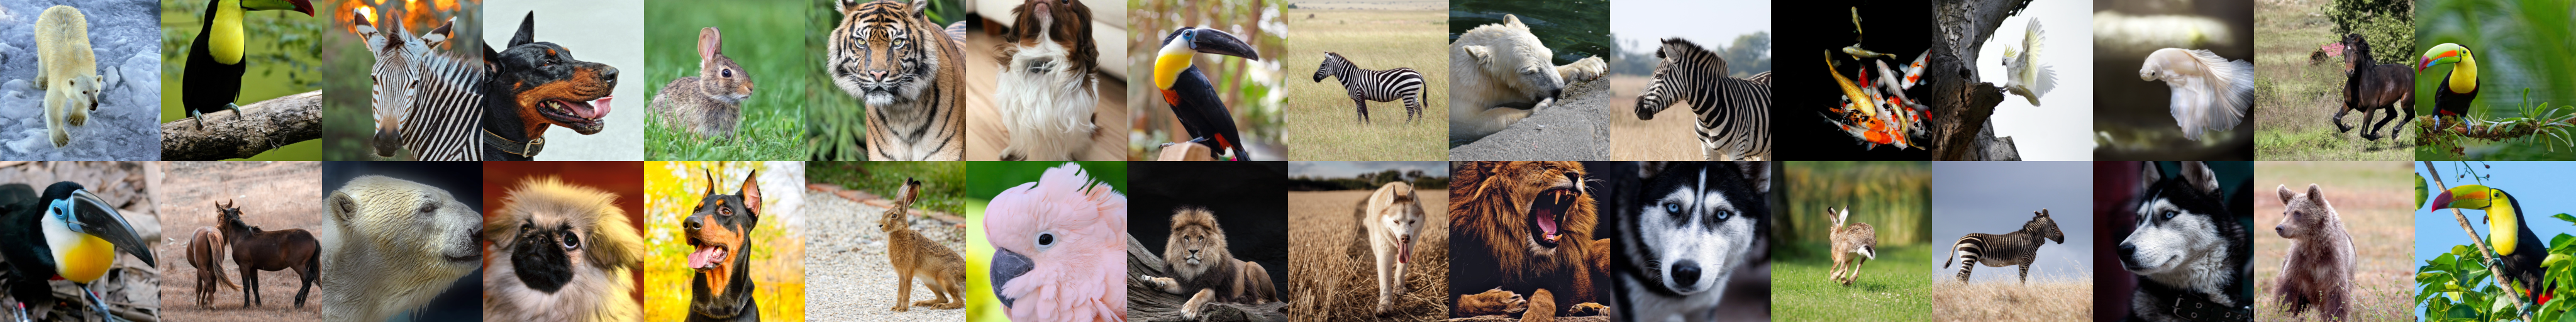

In [13]:
# Load data
batch_size = 32
data = HDF5DataModule(
            hdf5_file=data_dir,
            batch_size=batch_size,
            source_timestep=source_timestep,
            target_timestep=target_timestep,
            num_workers=8,
            train=False,
            test=True,
            group_name='test',
        )
data.setup(stage='test')
for batch in data.test_dataloader():
    for k, v in batch.items():
        if isinstance(v, torch.Tensor) or isinstance(v, np.ndarray):
            print(f"{k:<10} {v.shape}")
        elif isinstance(v, list):
            print(f"{k:<10} [{v[0]}, ...]")
        else:
            print(f"{k:<10} {type(v)}")
    break

# Load a batch
images = batch['image']
labels = batch['label']

print(f"Min images: {images.min():.2f}, Max images: {images.max():.2f}")

ims = tensor2im(images)
ims = ims_to_grid(ims, split=2, channel_last=True)
Image.fromarray(ims).show()

---
# Utility Functions

In [14]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
from torchvision.utils import make_grid
import scipy.fftpack
from typing import List



# === Helper: compute DCT ===
def compute_dct_log_magnitude(images: torch.Tensor) -> torch.Tensor:
    """
    Compute log-magnitude of 2D DCT for each image in a batch.
    Args:
        images (torch.Tensor): (B, C, H, W) in [0, 1]
    Returns:
        log_magnitude (torch.Tensor): (B, C, H, W)
    """
    images_np = images.cpu().numpy()
    dct_mags = []

    for img in images_np:
        dct_img = []
        for c in range(img.shape[0]):
            dct = scipy.fftpack.dct(scipy.fftpack.dct(img[c], axis=0, norm='ortho'), axis=1, norm='ortho')
            log_mag = np.log(np.abs(dct) + 1e-6)
            dct_img.append(log_mag)
        dct_mags.append(np.stack(dct_img, axis=0))
    
    return torch.tensor(np.stack(dct_mags), dtype=torch.float32)



# === Helper: decode latents at specific timesteps ===
def decode_intermediates(flow, vae, z, desired_ts, sample_kwargs):
    """
    Decode latent trajectories at specified timesteps from flow.generate().
    """
    num_steps = sample_kwargs.get("num_steps", 50)
    # Get all intermediates, shape: (num_steps+1, batch_size, C, H, W)
    intermediates = flow.generate(z, return_intermediates=True, **sample_kwargs)  # (T+1, B, C, H, W)

    decoded = []
    for t in desired_ts:
        idx = int(round(t * num_steps))     # Map t to index
        z_t = intermediates[idx]            # shape: (B, C, H, W)
        x_t = vae.decode(z_t)
        decoded.append(x_t.detach().cpu())
    return decoded




# === Plot (1): just the samples with timestep labels and arrow ===
import torchvision.transforms.functional as TF
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

def plot_decoded_steps(decoded_imgs, timesteps, title="Intermediate decoded samples"):
    """
    Plot decoded intermediate samples in a grid with timestep labels.

    Args:
        decoded_imgs: list of torch.Tensor images (B, C, H, W)
        timesteps: list of floats matching decoded_imgs
        title: str plot title
    """
    # Assume batch size = 1 for simplicity; decode_intermediates returns list of (B, C, H, W)
    imgs = torch.cat(decoded_imgs, dim=0)  # (num_steps, C, H, W)

    imgs = torch.stack([TF.resize(img, [128, 128]) for img in imgs])
    imgs = denorm_tensor(imgs.detach().cpu())
    grid = make_grid(imgs, nrow=len(imgs), padding=0)

    plt.figure(figsize=(2.5 * len(imgs), 3))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis('off')

    for i, t in enumerate(timesteps):
        plt.text(
            (i + 0.5) * grid.shape[2] / len(imgs), -10,
            f"t={t:.2f}", ha='center', va='bottom', fontsize=10
        )

    plt.title(title)
    plt.tight_layout()
    plt.show()




# === Plot (2): samples + DCT magnitude spectra in two rows ===
def plot_decoded_and_dct(decoded_imgs: List[torch.Tensor]):
    """
    Plot decoded samples and their DCT log-magnitude spectra in two rows.
    """
    images = torch.cat(decoded_imgs, dim=0).clamp(0, 1)  # (B, C, H, W)
    dct_mags = compute_dct_log_magnitude(images)

    # Normalize for visualization
    dct_mags -= dct_mags.amin(dim=(2,3), keepdim=True)
    dct_mags /= dct_mags.amax(dim=(2,3), keepdim=True)

    combined = torch.cat([images, dct_mags], dim=0)  # (2B, C, H, W)
    grid = make_grid(combined, nrow=len(decoded_imgs), padding=0)

    plt.figure(figsize=(len(decoded_imgs)*2, 4))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis('off')
    plt.title("Top: Decoded Samples | Bottom: Log DCT Magnitude (Spatial Frequency)")
    plt.tight_layout()
    plt.show()






#########################################################
#           Collect samples from the dataset            #
#########################################################
from collections import defaultdict
from typing import List, Tuple

def collect_samples(
    data,
    class_labels: List[int],
    source_timestep: float,
    samples_per_class: int = 10
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Collects a fixed number of samples per class from a validation dataloader.
    Returns latents, labels, and corresponding images.
    """
    collected_latents = defaultdict(list)
    collected_images = defaultdict(list)
    val_loader = data.test_dataloader()
    latent_key = f'latents_{source_timestep:.2f}'

    for batch_idx, batch in enumerate(val_loader):
        latents = batch[latent_key].detach().cpu()
        labels = batch['label'].view(-1).detach().cpu()
        images = batch['image'].detach().cpu()

        for label in class_labels:
            needed = samples_per_class - len(collected_latents[label])
            if needed <= 0:
                continue

            class_mask = labels == label
            selected_latents = latents[class_mask]
            selected_images = images[class_mask]

            if selected_latents.size(0) > 0:
                to_take = min(needed, selected_latents.size(0))
                collected_latents[label].extend(selected_latents[:to_take])
                collected_images[label].extend(selected_images[:to_take])

        if all(len(collected_latents[label]) >= samples_per_class for label in class_labels):
            print(f"[INFO] Collected enough samples for all classes after {batch_idx + 1} batches.")
            break

    all_latents, all_labels, all_images = [], [], []
    for label in class_labels:
        latents_list = collected_latents[label]
        images_list = collected_images[label]

        if len(latents_list) < samples_per_class:
            raise ValueError(f"Not enough samples collected for class {label}: got {len(latents_list)}")

        stacked_latents = torch.stack(latents_list[:samples_per_class], dim=0)
        stacked_images = torch.stack(images_list[:samples_per_class], dim=0)
        label_tensor = torch.full((samples_per_class,), label, dtype=torch.long)

        all_latents.append(stacked_latents)
        all_labels.append(label_tensor)
        all_images.append(stacked_images)

    return (
        torch.cat(all_latents, dim=0),
        torch.cat(all_labels, dim=0),
        torch.cat(all_images, dim=0)
    )


In [15]:
# Interpolation between Siberian Husky --> Pekinese
num_pairs = 1

class_labels = [250, 154]
samples_per_class = 2

# Collect samples
coll_latents, coll_labels, coll_images = collect_samples(
    data,
    class_labels=class_labels,
    source_timestep=source_timestep,
    samples_per_class=samples_per_class
)

# Get per-class latents and corresponding images
cls1_mask = coll_labels == class_labels[0]
cls2_mask = coll_labels == class_labels[1]

husky_noise = coll_latents[cls1_mask][:num_pairs]
pekin_noise = coll_latents[cls2_mask][:num_pairs]

husky_gt = coll_images[cls1_mask][:num_pairs]
pekin_gt = coll_images[cls2_mask][:num_pairs]

[INFO] Collected enough samples for all classes after 1 batches.


---
# SiT Inference w/o Guidance-Free Noise and CFG

Noise shape: torch.Size([1, 4, 32, 32])


100%|██████████| 100/100 [00:06<00:00, 16.19it/s]


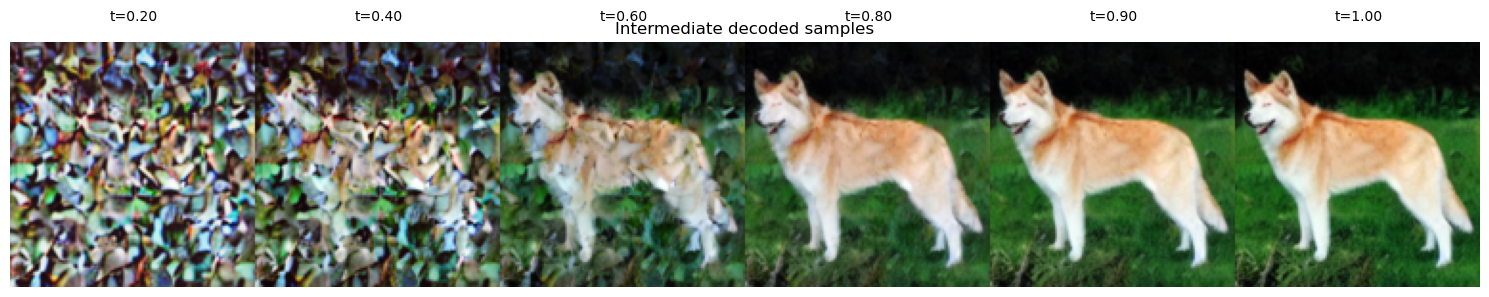

In [ ]:
timesteps = [0.2, 0.4, 0.6, 0.8, 0.9, 1.0]

num_steps = 100
cfg_scale = 1.0
class_labels = [250]

noise = torch.randn(1, 4, 32, 32, device=DEV)

print(f"Noise shape: {noise.shape}")

y = torch.tensor(class_labels, device=DEV)
y_null = torch.tensor([1000], device=DEV)

sample_kwargs = {
    "num_steps": num_steps,
    "y": y,
    "cfg_scale": cfg_scale,
    "cond_key": "y",
    "uc_cond": y_null,
}

noise_decoded_imgs = decode_intermediates(flow, vae, noise, timesteps, sample_kwargs)
plot_decoded_steps(noise_decoded_imgs, timesteps)


Noise shape: torch.Size([1, 4, 32, 32])


  4%|▍         | 4/100 [00:00<00:05, 17.14it/s]

100%|██████████| 100/100 [00:06<00:00, 16.35it/s]


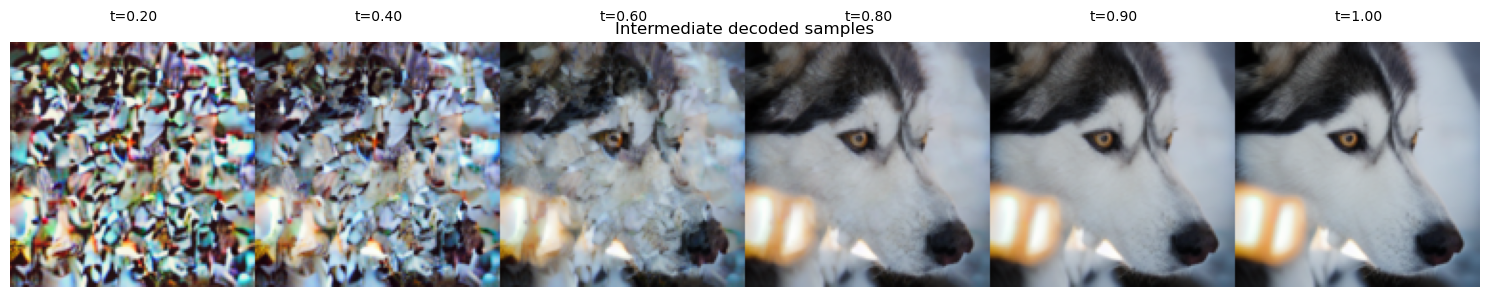

In [21]:
timesteps = [0.2, 0.4, 0.6, 0.8, 0.9, 1.0]

num_steps = 100
cfg_scale = 1.0

class_labels = [250]
noise = husky_noise.to(DEV)

print(f"Noise shape: {noise.shape}")

y = torch.tensor(class_labels, device=DEV)
y_null = torch.tensor([1000], device=DEV)

sample_kwargs = {
    "num_steps": num_steps,
    "y": y,
    "cfg_scale": cfg_scale,
    "cond_key": "y",
    "uc_cond": y_null,
}

gf_decoded_imgs = decode_intermediates(flow, vae, noise, timesteps, sample_kwargs)
plot_decoded_steps(gf_decoded_imgs, timesteps)
